In [1]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

os.environ['LOKY_MAX_CPU_COUNT'] = '4'

In [2]:
dataset_path = r'd:\AI Business Recomendation\datasets\dataset_ml_structured.csv'
dataset = pd.read_csv(dataset_path)

In [3]:
df = dataset.copy()

In [4]:
df = df[['feature_lat', 'feature_lon']]

print(df.head())

   feature_lat  feature_lon
0    11.101632    76.965305
1    11.015784    76.955423
2    11.082068    76.941241
3    11.084471    76.939729
4    11.100545    76.963745


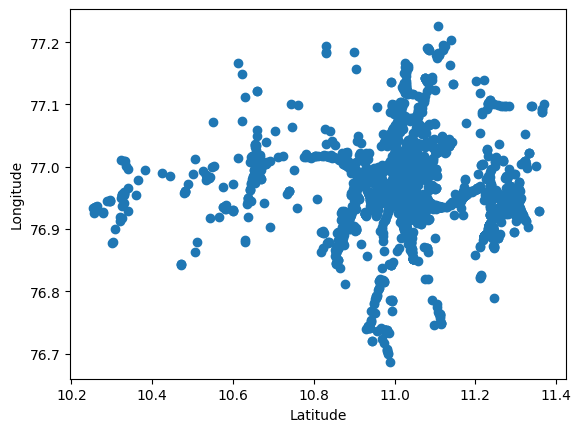

In [5]:
plt.scatter(df['feature_lat'], df['feature_lon'])
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.show()

In [6]:
km = KMeans(n_clusters=3, random_state=42, n_init='auto')

y_predicted = km.fit_predict(df)

print(y_predicted)

[2 2 2 ... 2 2 2]


In [7]:
df['cluster'] = y_predicted
df.head()

,feature_lat,feature_lon,cluster
0,11.101632,76.965305,2
1,11.015784,76.955423,2
2,11.082068,76.941241,2
3,11.084471,76.939729,2
4,11.100545,76.963745,2


In [ ]:
km.cluster_centers_

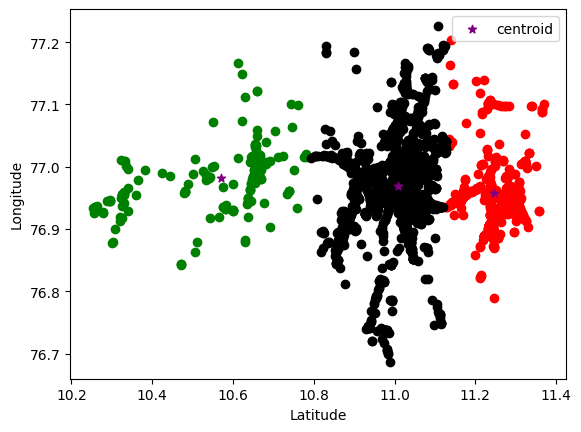

In [8]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1['feature_lat'], df1['feature_lon'], color='green')
plt.scatter(df2['feature_lat'], df2['feature_lon'], color='red')
plt.scatter(df3['feature_lat'], df3['feature_lon'], color='black')

plt.scatter(
    km.cluster_centers_[:,0],
    km.cluster_centers_[:,1],
    color='purple',
    marker='*',
    label='centroid'
)

plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.legend()
plt.show()

In [9]:
scaler = MinMaxScaler()

scaler.fit(df[['feature_lat']])
df['feature_lat'] = scaler.transform(df[['feature_lat']])

scaler.fit(df[['feature_lon']])
df['feature_lon'] = scaler.transform(df[['feature_lon']])

df.head()

,feature_lat,feature_lon,cluster
0,0.760453,0.516403,2
1,0.683561,0.498079,2
2,0.742930,0.471782,2
3,0.745082,0.468978,2
4,0.759479,0.513510,2


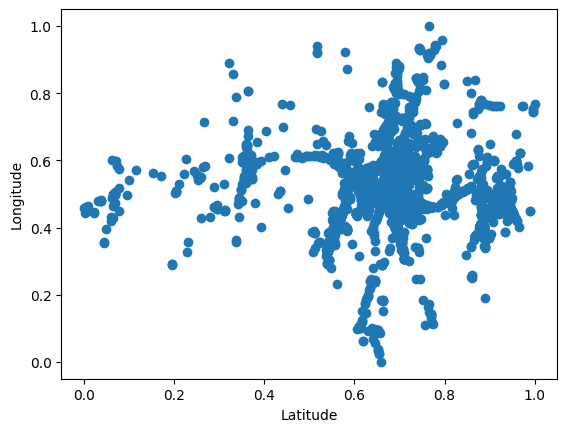

In [10]:
plt.scatter(df['feature_lat'], df['feature_lon'])
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.show()

In [11]:
km = KMeans(n_clusters=3, random_state=42, n_init='auto')

y_predicted = km.fit_predict(df[['feature_lat', 'feature_lon']])

print(y_predicted)

[2 2 2 ... 1 2 1]


In [12]:
df['cluster'] = y_predicted
df.head()

,feature_lat,feature_lon,cluster
0,0.760453,0.516403,2
1,0.683561,0.498079,2
2,0.742930,0.471782,2
3,0.745082,0.468978,2
4,0.759479,0.513510,2


In [ ]:
km.cluster_centers_

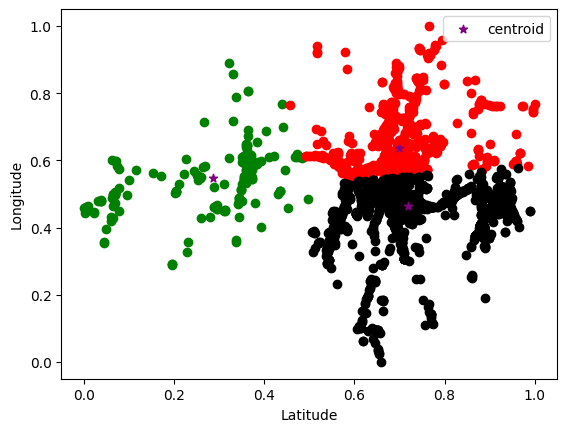

In [13]:
df1 = df[df.cluster == 0]
df2 = df[df.cluster == 1]
df3 = df[df.cluster == 2]

plt.scatter(df1['feature_lat'], df1['feature_lon'], color='green')
plt.scatter(df2['feature_lat'], df2['feature_lon'], color='red')
plt.scatter(df3['feature_lat'], df3['feature_lon'], color='black')

plt.scatter(
    km.cluster_centers_[:,0],
    km.cluster_centers_[:,1],
    color='purple',
    marker='*',
    label='centroid'
)

plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.legend()
plt.show()

In [14]:
sse = []

k_rng = range(1,10)

for k in k_rng:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(df[['feature_lat', 'feature_lon']])
    sse.append(km.inertia_)

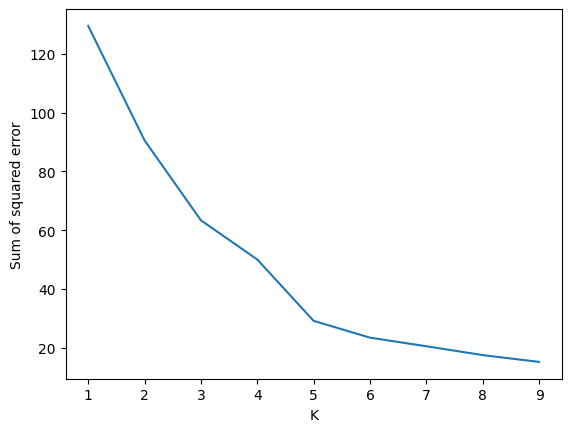

In [15]:
plt.xlabel('K')
plt.ylabel('Sum of squared error')

plt.plot(k_rng, sse)

plt.show()

In [16]:
with open('k_means_clustering_own_dataset.pkl','wb') as file:
    pickle.dump(km,file)

In [17]:
with open('k_means_clustering_own_dataset.pkl', 'rb') as file:
    model = pickle.load(file)

print(model.cluster_centers_)

[[0.66190011 0.13248745]
 [0.70068742 0.61242283]
 [0.34922011 0.56893089]
 [0.6440078  0.39873973]
 [0.74267704 0.79955679]
 [0.89339245 0.47624938]
 [0.57372511 0.57638899]
 [0.08652309 0.47668694]
 [0.68455217 0.5025402 ]]
